# Urban Biotope Semantic Segmentation with SegFormer

This notebook trains a **semantic segmentation model** to classify **biotope types in Zurich** using high-resolution aerial imagery (SWISSIMAGE 10 cm).

The workflow:

1. Load dataset from Google Drive
2. Prepare PyTorch dataset
3. Apply preprocessing and augmentations
4. Fine-tune a SegFormer model
5. Evaluate performance
6. Visualize predictions

We use a **transformer-based segmentation model (SegFormer)** from Hugging Face.


## Setup

#### Install Dependencies


In [ ]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q rasterio albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


#### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set datapath:

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/impervious_built-up"


#### Check Runtime
Check if T4 runtime is working correctly

In [ ]:
import torch

print("GPU:", torch.cuda.is_available())


GPU: True


# Modeling

## Import Libraries

In [ ]:
import os
import numpy as np
import torch
import rasterio
from PIL import Image

from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    TrainingArguments,
    Trainer
)

import albumentations as A


## Define Class Labels

In [ ]:
id2label = {
0: "Impervious / Built-up",
1: "Forest & Dense Canopy",
2: "Urban Trees & Bushes",
3: "Managed Green Spaces",
4: "Standard Grassland",
5: "Ecologically Valuable Meadow",
6: "Agriculture & Orchards",
7: "Water Bodies"
}

label2id = {v:k for k,v in id2label.items()}
num_classes = len(id2label)


## Dataset Structure

Each datapoint consists of:

Image patch  
- RGB satellite image  
- size: 1024 × 1024  

Mask patch  
- same spatial resolution  
- each pixel contains a **class ID (0–7)**  
- 255 represents **ignore / unlabeled**

During training we randomly crop patches to **512×512**, which improves
generalization and fits GPU memory.


## Dataset Class

In [ ]:
class BiotopeDataset(Dataset):

    def __init__(self, root_dir, split, processor, transform=None):

        self.img_dir = os.path.join(root_dir, split, "images")
        self.mask_dir = os.path.join(root_dir, split, "masks")

        self.images = sorted(os.listdir(self.img_dir))
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        with rasterio.open(img_path) as src:
            image = src.read([1,2,3])
            image = np.transpose(image, (1,2,0))

        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        encoded = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        encoded = {k:v.squeeze() for k,v in encoded.items()}

        return encoded


## Load Model

We use **SegFormer-B3**, a transformer-based semantic segmentation model.

Advantages:

- strong performance on high-resolution imagery
- efficient transformer architecture
- robust multi-scale feature extraction


In [27]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation, SegformerConfig

# Load model configuration and modify image_size to the new target resolution
#model_config = SegformerConfig.from_pretrained("nvidia/segformer-b3-finetuned-ade-512-512")
model_config = SegformerConfig.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model_config.image_size = config["target_input_resolution"]
model_config.num_labels = num_classes
model_config.id2label = id2label
model_config.label2id = label2id

processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b3-finetuned-ade-512-512",
    size={'height': config["target_input_resolution"], 'width': config["target_input_resolution"]},
    do_resize=True # Ensure resizing is performed to the new target size
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b3-finetuned-ade-512-512",
    config=model_config, # Pass the modified config to the model
    ignore_mismatched_sizes=True
)

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                                                                         | Status     |                                                                                                       
----------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------------------------
segformer.encoder.block.{0, 1, 2, 3}.{2...17}.attention.self.query.weight   | UNEXPECTED |                                                                                                       
segformer.encoder.block.{0, 1, 2}.{2...17}.attention.self.layer_norm.bias   | UNEXPECTED |                                                                                                       
segformer.encoder.block.{0, 1, 2, 3}.{2...17}.layer_norm_2.weight           | UNEXPECTED |                                         

## Run Configuration

In [34]:
import os
import json

config = {
    "version_tag": "run_b0_01", # Unique identifier for this training run
    "num_epochs": 5, # Number of training epochs
    "learning_rate": 6e-5, # Learning rate for the optimizer
    "train_batch_size": 2, # Batch size for training (actual batch size per step)
    "val_batch_size": 2, # Batch size for validation
    "subset_ratio": 0.01, # Ratio of the dataset to use for training/validation (0.0 to 1.0)
    "initial_crop_size": 512, # Size of the random/center crops from the original image
    "target_input_resolution": 256, # Final desired height/width of images after augmentation and as input to the model
    "gradient_accumulation_steps": 4, # Number of batches to accumulate gradients over
    "use_fp16": True # Whether to use mixed precision training (float16)
}

# Define output directory based on version_tag
OUTPUT_ROOT_DIR = "/content/drive/MyDrive/segformer_biotope_runs"
OUTPUT_DIR = os.path.join(OUTPUT_ROOT_DIR, config["version_tag"])

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}")

# Save the configuration to the output directory
with open(os.path.join(OUTPUT_DIR, "run_config.json"), "w") as f:
    json.dump(config, f, indent=4)

Output will be saved to: /content/drive/MyDrive/segformer_biotope_runs/run_b0_01


## Data Augmentation

In [35]:
train_transform = A.Compose([
    A.RandomCrop(config["initial_crop_size"], config["initial_crop_size"]), # First, crop the image
    A.Resize(config["target_input_resolution"], config["target_input_resolution"]), # Then, resize (downsample) it
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5)
])

val_transform = A.Compose([
    A.CenterCrop(config["initial_crop_size"], config["initial_crop_size"]), # First, crop the image
    A.Resize(config["target_input_resolution"], config["target_input_resolution"]) # Then, resize (downsample) it
])

## Load Dataset

In [36]:
train_dataset = BiotopeDataset(
    DATA_ROOT,
    "train",
    processor,
    transform=train_transform
)

val_dataset = BiotopeDataset(
    DATA_ROOT,
    "val",
    processor,
    transform=val_transform
)


#### Subset Train and Val Dataset for Testing

In [37]:
from torch.utils.data import Subset
import numpy as np

SUBSET_RATIO = config["subset_ratio"]

train_size = int(len(train_dataset) * SUBSET_RATIO)
val_size = int(len(val_dataset) * SUBSET_RATIO)

train_indices = np.random.choice(len(train_dataset), train_size, replace=False)
val_indices = np.random.choice(len(val_dataset), val_size, replace=False)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print("Train subset:", len(train_dataset))
print("Val subset:", len(val_dataset))

Train subset: 126
Val subset: 14


## Training Loop

In [38]:
# =====================
# CUSTOM TRAINING LOOP
# =====================

import torch
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Initialize GradScaler for mixed precision training if enabled
if config["use_fp16"]:
    scaler = torch.cuda.amp.GradScaler()
else:
    scaler = None

# -------- DATALOADERS --------

train_loader = DataLoader(train_dataset, batch_size=config["train_batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=config["val_batch_size"], shuffle=False, num_workers=2)

# -------- OPTIMIZER --------

optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# -------- METRIC: mIoU --------

def get_intersection_union_per_class(preds, labels, num_classes=8):
    # Flatten predictions and labels, ignoring the 255 (ignore_index)
    preds = preds.flatten()
    labels = labels.flatten()

    valid_pixels = labels != 255
    preds = preds[valid_pixels]
    labels = labels[valid_pixels]

    # Initialize per-class intersection and union
    intersection = np.zeros(num_classes)
    union = np.zeros(num_classes)

    for cls in range(num_classes):
        pred_mask = (preds == cls)
        label_mask = (labels == cls)

        intersection[cls] = (pred_mask & label_mask).sum()
        union[cls] = (pred_mask | label_mask).sum()

    return intersection, union

# -------- TRAINING SETTINGS --------

num_epochs = config["num_epochs"]
early_stop_miou = 0.65   # stop if reached
best_val_miou = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_miou": [],
    "val_miou": []
}

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(num_epochs):

    # Clear CUDA cache at the beginning of each epoch to free up memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    # ================= TRAIN =================
    model.train()

    train_loss = 0
    train_total_intersections = np.zeros(num_classes)
    train_total_unions = np.zeros(num_classes)

    optimizer.zero_grad() # Zero gradients once per accumulation cycle

    for batch_idx, batch in enumerate(tqdm(train_loader, desc="Training")):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        with torch.cuda.amp.autocast(enabled=config["use_fp16"]): # Enable autocasting for mixed precision
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / config["gradient_accumulation_steps"] # Scale loss by accumulation steps

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        train_loss += loss.item() * config["gradient_accumulation_steps"] # Unscale loss for logging

        # Perform optimizer step and zero gradients every `gradient_accumulation_steps`
        if (batch_idx + 1) % config["gradient_accumulation_steps"] == 0 or (batch_idx + 1) == len(train_loader):
            if scaler:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

        logits = outputs.logits

        # Upsample to match label size
        logits = F.interpolate(
            logits,
            size=labels.shape[-2:],   # (H, W)
            mode="bilinear",
            align_corners=False
        )

        preds = logits.argmax(dim=1).cpu().numpy()
        labels_np = labels.cpu().numpy()

        intersections, unions = get_intersection_union_per_class(preds, labels_np, num_classes)
        train_total_intersections += intersections
        train_total_unions += unions

        # Explicitly delete variables to free memory
        del pixel_values, labels, outputs, loss, logits, preds, labels_np, intersections, unions
        torch.cuda.empty_cache()

    train_loss /= len(train_loader)

    # Calculate mIoU for the epoch
    train_ious = [inter / un for inter, un in zip(train_total_intersections, train_total_unions) if un > 0]
    train_miou = np.mean(train_ious) if len(train_ious) > 0 else 0

    # ================= VALIDATION =================
    model.eval()

    val_loss = 0
    val_total_intersections = np.zeros(num_classes)
    val_total_unions = np.zeros(num_classes)

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(val_loader, desc="Validation")):

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=config["use_fp16"]): # Enable autocasting for mixed precision
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss

            val_loss += loss.item()

            logits = outputs.logits

            # Upsample to match label size
            logits = F.interpolate(
                logits,
                size=labels.shape[-2:],   # (H, W)
                mode="bilinear",
                align_corners=False
            )

            preds = logits.argmax(dim=1).cpu().numpy()
            labels_np = labels.cpu().numpy()

            intersections, unions = get_intersection_union_per_class(preds, labels_np, num_classes)
            val_total_intersections += intersections
            val_total_unions += unions

            # Explicitly delete variables to free memory
            del pixel_values, labels, outputs, loss, logits, preds, labels_np, intersections, unions
            torch.cuda.empty_cache()

    val_loss /= len(val_loader)

    # Calculate mIoU for the epoch
    val_ious = [inter / un for inter, un in zip(val_total_intersections, val_total_unions) if un > 0]
    val_miou = np.mean(val_ious) if len(val_ious) > 0 else 0

    # ================= LOGGING =================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_miou"].append(train_miou)
    history["val_miou"].append(val_miou)

    print(f"\nEpoch {epoch+1} Results:")
    print(f"Train Loss: {train_loss:.4f} | Train mIoU: {train_miou:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   mIoU: {val_miou:.4f}")

    # ================= EARLY STOPPING =================

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pth"))
        print("✅ Best model saved!")

    if val_miou >= early_stop_miou:
        print(f"\n🎯 Early stopping: reached mIoU {val_miou:.4f}")
        break

print("\n🏁 Training complete!")

/tmp/ipykernel_2752/2339361654.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



🚀 Epoch 1/5


Training:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_2752/2339361654.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=config["use_fp16"]): # Enable autocasting for mixed precision
Validation:   0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipykernel_2752/2339361654.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=config["use_fp16"]): # Enable autocasting for mixed precision
Validation: 100%|██████████| 7/7 [00:11<00:00,  1.64s/it]



Epoch 1 Results:
Train Loss: 1.9764 | Train mIoU: 0.0899
Val   Loss: 1.6889 | Val   mIoU: 0.1288
✅ Best model saved!

🚀 Epoch 2/5


Training:   3%|▎         | 2/63 [00:14<07:08,  7.03s/it]


KeyboardInterrupt: 

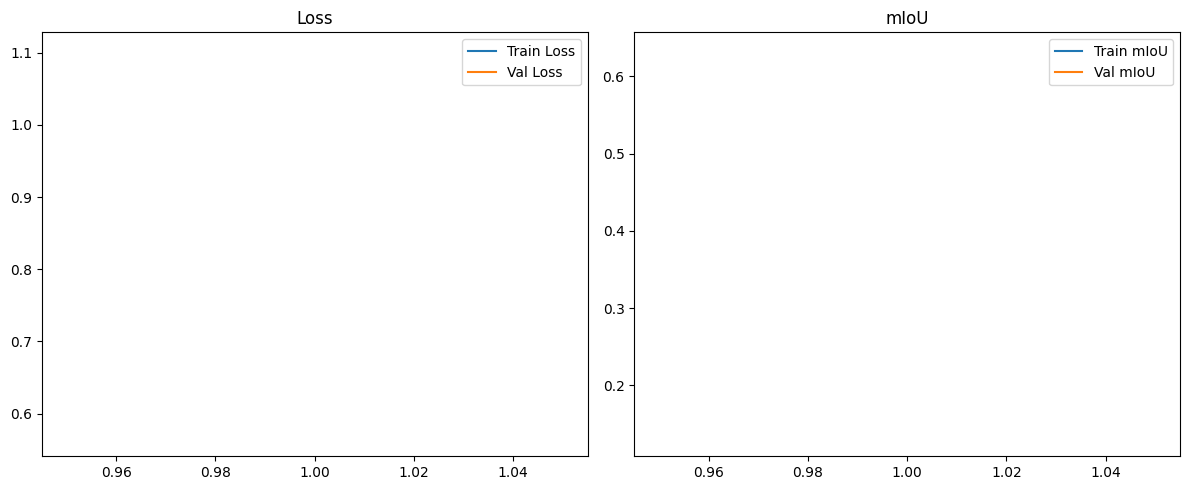

In [ ]:
import matplotlib.pyplot as plt
import os

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# mIoU
plt.subplot(1,2,2)
plt.plot(epochs, history["train_miou"], label="Train mIoU")
plt.plot(epochs, history["val_miou"], label="Val mIoU")
plt.legend()
plt.title("mIoU")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history_plot.png")) # Save the plot
plt.show()

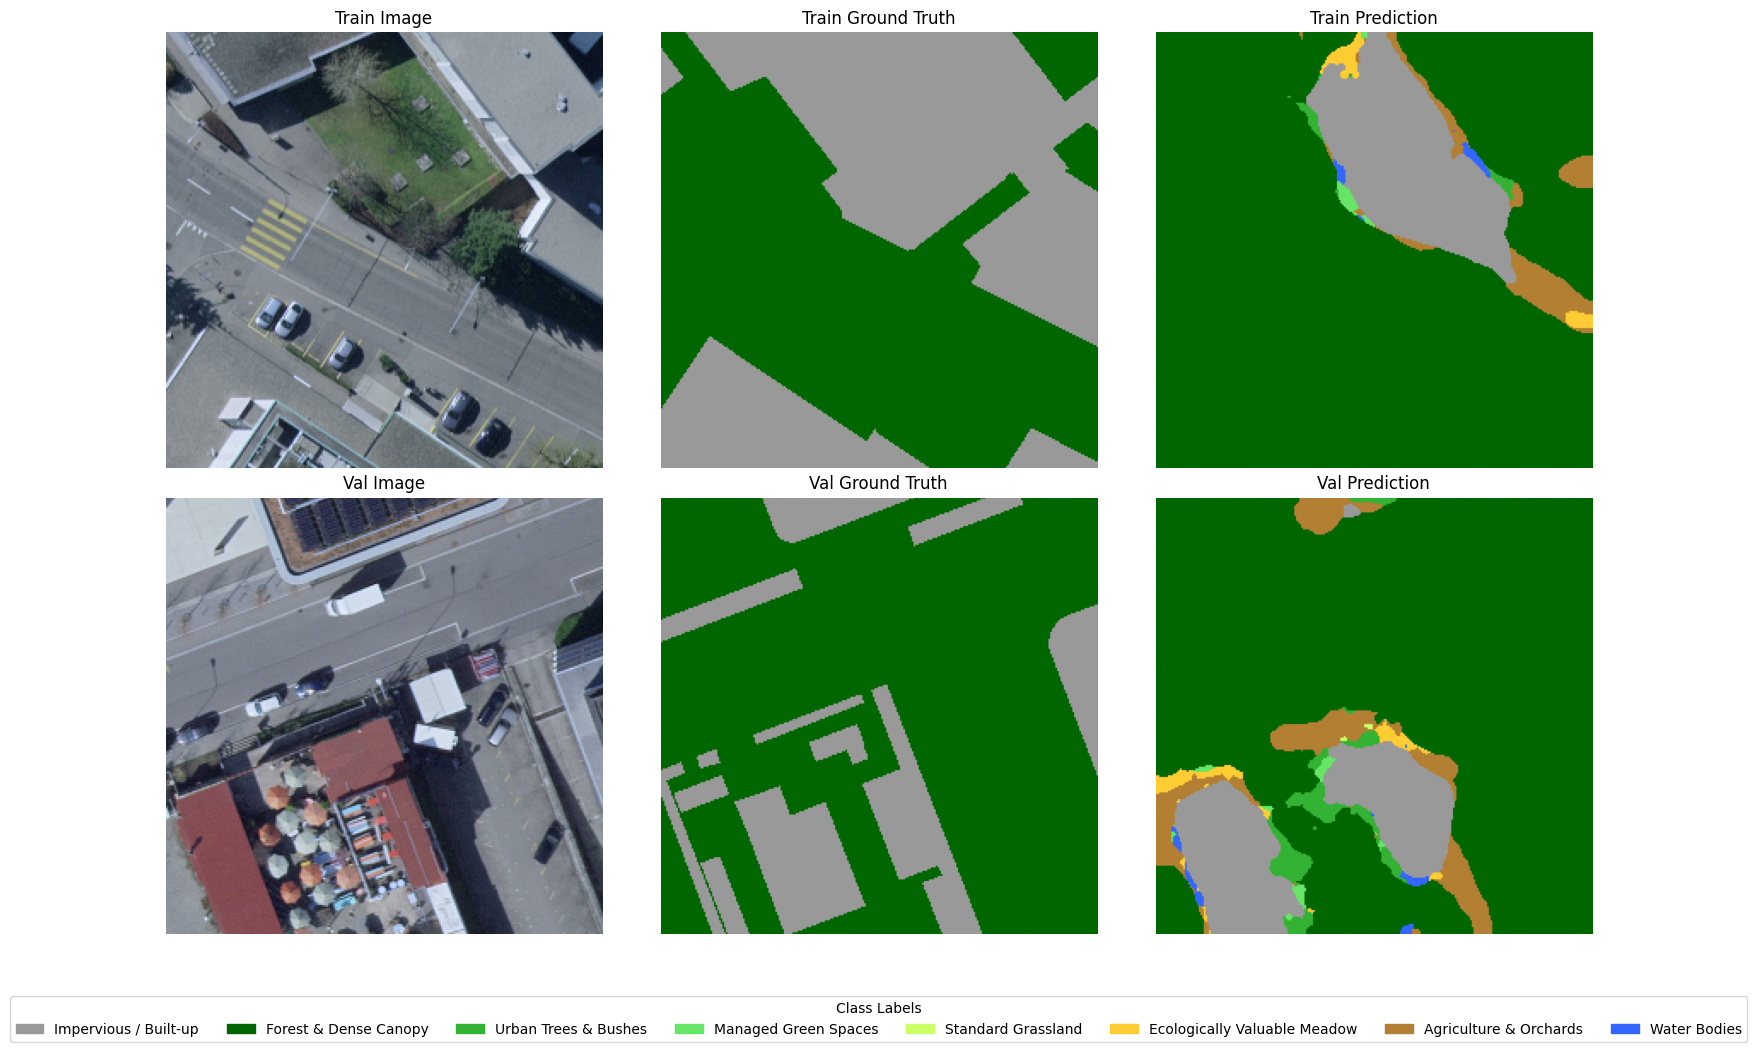

In [42]:
# ============================================================
# OVERFIT DEBUG VISUALIZATION (TRAIN vs VAL)
# ============================================================

import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

model.eval()

def get_prediction(sample):

    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
    labels = sample["labels"].cpu().numpy()

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    logits = outputs.logits

    # Upsample to match label size
    logits = F.interpolate(
        logits,
        size=labels.shape,
        mode="bilinear",
        align_corners=False
    )

    pred = logits.argmax(dim=1).cpu().numpy()[0]

    image = sample["pixel_values"].cpu().numpy()
    image = np.transpose(image, (1,2,0))
    image = (image - image.min()) / (image.max() - image.min())

    return image, labels, pred


# -------- GET ONE TRAIN + ONE VAL SAMPLE --------

train_sample = train_dataset[4]   # should overfit here
val_sample   = val_dataset[4]

train_img, train_gt, train_pred = get_prediction(train_sample)
val_img, val_gt, val_pred       = get_prediction(val_sample)

# -------- COLOR MAP --------

colors = [
    (0.6, 0.6, 0.6),  # built-up
    (0.0, 0.4, 0.0),  # forest
    (0.2, 0.7, 0.2),  # trees
    (0.4, 0.9, 0.4),  # managed
    (0.8, 1.0, 0.4),  # grass
    (1.0, 0.8, 0.2),  # meadow
    (0.7, 0.5, 0.2),  # agriculture
    (0.2, 0.4, 1.0)   # water
]
cmap = ListedColormap(colors)

# -------- PLOT --------

plt.figure(figsize=(15,10))

# --- TRAIN ROW ---
plt.subplot(2,3,1)
plt.title("Train Image")
plt.imshow(train_img)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Train Ground Truth")
plt.imshow(train_gt, cmap=cmap, vmin=0, vmax=7)
plt.axis("off")

plt.subplot(2,3,3)
plt.title("Train Prediction")
plt.imshow(train_pred, cmap=cmap, vmin=0, vmax=7)
plt.axis("off")

# --- VAL ROW ---
plt.subplot(2,3,4)
plt.title("Val Image")
plt.imshow(val_img)
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Val Ground Truth")
plt.imshow(val_gt, cmap=cmap, vmin=0, vmax=7)
plt.axis("off")

plt.subplot(2,3,6)
plt.title("Val Prediction")
plt.imshow(val_pred, cmap=cmap, vmin=0, vmax=7)
plt.axis("off")

# --- LEGEND ---
patches = []
for class_id, class_name in id2label.items():
    if class_id < len(colors): # Ensure class_id is within the bounds of the colors list
        patch = mpatches.Patch(color=colors[class_id], label=class_name)
        patches.append(patch)

plt.figlegend(handles=patches, loc='lower center', ncol=len(id2label), bbox_to_anchor=(0.5, -0.05), title="Class Labels")

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make space for the legend
plt.show()